# Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from tqdm import tqdm
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from utils import get_regression_metrics

In [3]:
# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Adjust the width of each column if necessary.
pd.set_option("display.max_colwidth", None)

# Increase the total width of the display
pd.set_option("display.width", 0)

## Paso 1: Recopilación de datos y definición del problema

In [4]:
df = pd.read_csv('../data/raw/demographic_health_data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

`FIPS` - Code for the County  
`TOT_POP` - Total Population (this data as well as all Age and Race data is pulled from the 2019 Population Estimates of the US Census)  
`0-9` - Population aged 0-9 (all of the other age columns are the same but with varying age)  
`0-9 y/o % of total pop` - % of the population aged 0-9  
`10-19 y/o % of total pop`  
`20-29 y/o % of total pop`  
`30-39 y/o % of total pop`  
`40-49 y/o % of total pop`  
`60-69 y/o % of total pop`  
`70-79 y/o % of total pop`  
`80+ y/o % of total pop`  
`White-alone pop` - Population that is White only,All of the other age columns are the same but with varying age  
`% White-alone` - % of population that is White only  
`Black-alone pop`  
`% Black-alone`  
`Native American/American Indian-alone pop`  
`% NA/AI-alone`  
`Asian-alone pop`  
`Hawaiian/Pacific Islander-alone pop`  
`% Hawaiian/PI-alone`  
`Two or more races pop`  
`% Two or more races`  
`N_POP_CHG_2018`- Numeric Change in resident total population 7/1/2017 to 7/1/2018  
`GQ_ESTIMATES_2018` - 7/1/2018 Group Quarters total population estimate  
`R_birth_2018` - Birth rate in period 7/1/2017 to 6/30/2018  
`R_death_2018` - Death rate in period 7/1/2017 to 6/30/2018  
`R_NATURAL_INC_2018`- Natural increase rate in period 7/1/2016 to 6/30/2017  
`R_INTERNATIONAL_MIG_2018`- Net international migration rate in period 7/1/2017 to 6/30/2018  
`R_DOMESTIC_MIG_2018`- Net domestic migration rate in period 7/1/2017 to 6/30/2018  
`R_NET_MIG_2018` - Net migration rate in period 7/1/2017 to 6/30/2018  
`Less than a high school diploma 2014-18`- Education variables are self explanatory, first 4 are number and second 4 are %  
`High school diploma only 2014-18`  
`Some college or associate's degree 2014-18`  
`Bachelor's degree or higher 2014-18`  
`Percent of adults with less than a high school diploma 2014-18`  
`Percent of adults with a high school diploma only 2014-18`  
`Percent of adults completing some college or associate's degree 2014-18`  
`Percent of adults with a bachelor's degree or higher 2014-18`  
`POVALL_2018` - Estimate of people of all ages in poverty 2018  
`PCTPOVALL_2018` - Estimated percent of people of all ages in poverty 2018  
`PCTPOV017_2018` - Estimated percent of people age 0-17 in poverty 2018  
`PCTPOV517_2018`- Estimate of related children age 5-17 in families in poverty 2018  
`MEDHHINC_2018` - Estimate of median household income 2018  
`CI90LBINC_2018` - 90% confidence interval lower bound of estimate of median household income 2018  
`CI90UBINC_2018` -90% confidence interval upper bound of estimate of median household income 2018  
`Civilian_labor_force_2018` - Civilian labor force annual average  
`Employed_2018`- Number employed annual average  
`Unemployed_2018`- Number unemployed annual average  
`Unemployment_rate_2018`- Unemployment rate  
`Med_HH_Income_Percent_of_State_Total_2018` - County Household Median Income as a percent of the State Total Median Household Income, 2018  
`Active Physicians per 100000 Population 2018 (AAMC)` - Total Active Patient Care Physicians per 100,000 Population, 2018 (Assumed identical to state)  
`Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)`- Active Primary Care Physicians per 100,000 Population, 2018 (Assumed identical to state)  
`Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)` - Active Patient Care Primary Care Physicians per 100,000 Population, 2018 (Assumed identical to state)  
`Active General Surgeons per 100000 Population 2018 (AAMC)` - Active General Surgeons per 100,000 Population, 2018 (Assumed identical to state)  
`Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)` - Active Patient Care General Surgeons per 100,000 Population, 2018 (Assumed identical to state)  
`Total nurse practitioners (2019)` - Total nurses (2019) - Assumed proportion to fraction of state population living in county  
`Total physician assistants (2019)` - Total physical assistants (2019) - Assumed proportion to fraction of state population living in county  
`Total Hospitals (2019)` - Total Hospitals (2019) (Assumed proportion to fraction of state population living in county)  
`Internal Medicine Primary Care (2019)` - Active Internal Medicine Primary Care Physicians (2019) (Assumed proportion to fraction of state population living in county)  
`Family Medicine/General Practice Primary Care (2019)` - Active Family Medicine/General Practice Primary Care Physicians (2019) (Assumed proportion to fraction of state population living in county)  
`Total Specialist Physicians (2019)`- Sum of Psychiatry, Surgery, Anesthesiology, Emergency Med, Radiology, Cardiology, Oncology, Endocrinology, and Other specialists (2019) (Assumed proportion to fraction of state population living in county  
`ICU Beds_x` - Number of ICU beds per county  
`Population Aged 60+` -Population aged 60+ (all of the other age columns are the same but with varying age)  
`Percent of Population Aged 60+` - % of the population aged 60+  
`STATE_FIPS` - FIPS Code for the State  
`county_pop2018_18 and older` - Population aged 18+ per county in 2018  
`anycondition_prevalence` - A prevalence rate isÂ the total number of cases of a disease existing in a population divided by the total population  
`anycondition_Lower 95% CI` - CI means confidence interval  
`anycondition_Upper 95% CI`  
`anycondition_number` - Population with anycondition  
`Obesity_prevalence`  
`Obesity_Lower 95% CI`  
`Obesity_Upper 95% CI`  
`Obesity_number` - Population with Obesity  
`Heart disease_prevalence`  
`Heart disease_Lower 95% CI`  
`Heart disease_Upper 95% CI`  
`Heart disease_number` - Population with Heart Disease  
`COPD_prevalence`  
`COPD_Lower 95% CI`  
`COPD_Upper 95% CI`  
`COPD_number` - Population with COPD  
`diabetes_prevalence`  
`diabetes_Lower 95% CI`  
`diabetes_Upper 95% CI`  
`diabetes_number` - Population with diabetes  
`CKD_prevalence`  
`CKD_Lower 95% CI`  
`CKD_Upper 95% CI`  
`CKD_number` Population with CKD  
`Urban_rural_code` - It distinguishes metropolitan (metro) counties by the population size of their metro area, and nonmetropolitan (nonmetro) counties by degree of urbanization and adjacency to a metro area or areas  
Metro counties:  
1 (Counties in metro areas of 1 million population or more)  
2 (Counties in metro areas of 250,000 to 1 million population)  
3 (Counties in metro areas of fewer than 250,000 population)  
Nonmetro counties:  
4 (Urban population of 20,000 or more, adjacent to a metro area)  
5 (Urban population of 20,000 or more, not adjacent to a metro area)  
6 (Urban population of 2,500 to 19,999, adjacent to a metro area)  
7 (Urban population of 2,500 to 19,999, not adjacent to a metro area)  
8 (Completely rural or less than 2,500 urban population, adjacent to a metro area)  
9 (Completely rural or less than 2,500 urban population, not adjacent to a metro area)  
88 (Unknown-Alaska/Hawaii State/not official USDA Rural-Urban Continuum code)  
99 (Unknown/not official USDA Rural-Urban Continuum code)  

> Hemos elegido la variable `ICU Beds_x` como variable objetivo (y) porque representa un recurso sanitario crítico y permite evaluar la capacidad hospitalaria de cada condado. 

In [5]:
df.shape

(3140, 108)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.000000,18180.500000,29178.000000,45081.500000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.000000,10963.250000,25800.500000,67913.000000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.000000,1280.500000,3057.000000,8097.000000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.000000,10.594639,11.802727,12.951840,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.000000,1374.500000,3274.000000,8822.250000,1.239139e+06
10-19 y/o % of total pop,3140.0,12.694609,1.815044,0.000000,11.674504,12.687422,13.659282,2.330437e+01
20-29,3140.0,14469.331529,49577.725396,0.000000,1263.750000,3108.000000,8976.250000,1.557073e+06
20-29 y/o % of total pop,3140.0,12.283979,3.126297,0.000000,10.496774,11.772649,13.182260,3.757020e+01
30-39,3140.0,13916.490127,48990.951710,11.000000,1232.750000,3000.500000,8314.250000,1.501844e+06
30-39 y/o % of total pop,3140.0,11.751535,1.696599,6.092789,10.689322,11.580861,12.639379,2.222513e+01


> ### Observaciones:
>
> - Existen un total de 3140 filas y 108 columnas.
> - Ninguna de las variables contiene valores nulos.
> - Los datos incluyen 106 características numéricas y 2 características categóricas.

## Paso 2: EDA

### Limpieza de datos: Eliminar duplicados

In [8]:
df_original = df.copy()
df_original.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
5       False
6       False
7       False
8       False
9       False
10      False
11      False
12      False
13      False
14      False
15      False
16      False
17      False
18      False
19      False
20      False
21      False
22      False
23      False
24      False
25      False
26      False
27      False
28      False
29      False
30      False
31      False
32      False
33      False
34      False
35      False
36      False
37      False
38      False
39      False
40      False
41      False
42      False
43      False
44      False
45      False
46      False
47      False
48      False
49      False
50      False
51      False
52      False
53      False
54      False
55      False
56      False
57      False
58      False
59      False
60      False
61      False
62      False
63      False
64      False
65      False
66      False
67      False
68      False
69      False
70      False
71    

In [10]:
df.duplicated().sum()

np.int64(0)

> #### Observaciones: 
>
No hay filas duplicadas. Ahora deberíamos revisar si existen variables con valores nulos.

In [11]:
df.isnull().mean().sort_values(ascending=False).head(20)

fips                        0.0
TOT_POP                     0.0
0-9                         0.0
0-9 y/o % of total pop      0.0
19-Oct                      0.0
10-19 y/o % of total pop    0.0
20-29                       0.0
20-29 y/o % of total pop    0.0
30-39                       0.0
30-39 y/o % of total pop    0.0
40-49                       0.0
40-49 y/o % of total pop    0.0
50-59                       0.0
50-59 y/o % of total pop    0.0
60-69                       0.0
60-69 y/o % of total pop    0.0
70-79                       0.0
70-79 y/o % of total pop    0.0
80+                         0.0
80+ y/o % of total pop      0.0
dtype: float64

> #### Observaciones: 
>
> No hay columnas con valores nulos. Hemos decidido eliminar las columnas de rangos de edades porque ya disponemos del porcentaje correspondiente; lo mismo ocurre con las variables de raza y educación, ya que contamos con los valores en porcentaje y no necesitamos duplicar la información. 
Para decidir si podemos eliminar alguna variable numérica adicional, será necesario realizar un análisis más profundo para determinar si alguna de ellas es irrelevante.

In [12]:
df.drop(['0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop', 'Black-alone pop', 'Population Aged 60+',
         'Native American/American Indian-alone pop', 'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop',
         'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18"], axis=1, inplace=True)
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,27.0,35.7,25.1,12.2,6788,30.9,43.9,36.7,34382,31157,37607,8373,7940,433,5.2,34382,68.9,217.1,196.7,77.2,71.2,7.6,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Barbour,Alabama,1,5,19689,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,22400,-15

### Análisis de Variables

> Tenemos solamente dos variables categoricas: `COUNTY_NAME` y `STATE_NAME`:

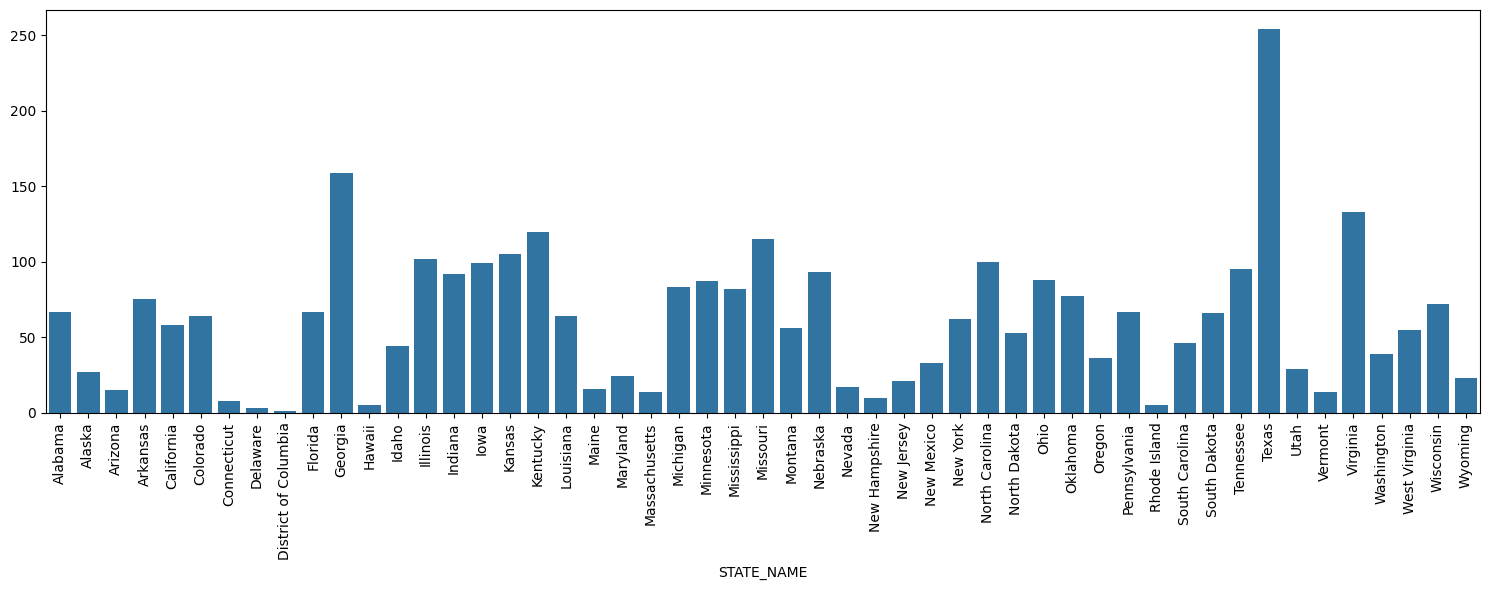

In [13]:
fig, axis = plt.subplots(1, 1, figsize=(15,6))

sns.countplot(ax=axis, data=df, x='STATE_NAME').set(ylabel=None)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [14]:
# How many counties we have
df['COUNTY_NAME'].nunique()

1841

<Axes: xlabel='COUNTY_NAME'>

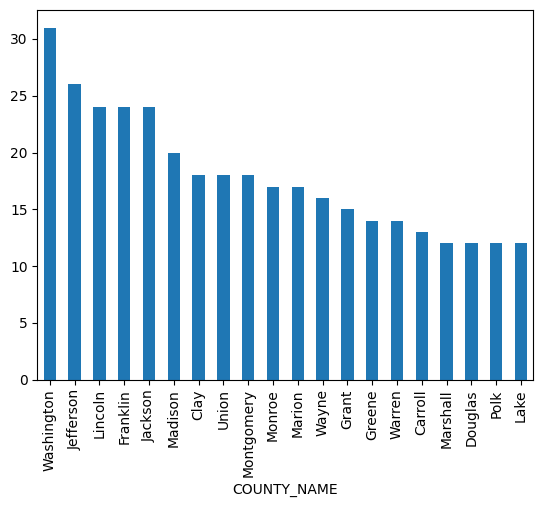

In [15]:
# Top 20 
df['COUNTY_NAME'].value_counts().head(20).plot(kind='bar')

In [16]:
# See how many different states each COUNTY_NAME has
county_state = df.groupby('COUNTY_NAME')['STATE_NAME'].nunique().sort_values(ascending=False)
county_state.head(20)


COUNTY_NAME
Washington    31
Jefferson     26
Franklin      24
Lincoln       24
Jackson       24
Madison       20
Clay          18
Montgomery    18
Union         18
Marion        17
Monroe        17
Wayne         16
Grant         15
Greene        14
Warren        14
Carroll       13
Johnson       12
Lake          12
Lee           12
Clark         12
Name: STATE_NAME, dtype: int64

> #### Observaciones: 
>
> - Texas es el valor más alto con diferencia (alrededor de 250). Varios estados pequeños o con menos población (por ejemplo Delaware, Rhode Island, Vermont) muestran valores muy bajos.
> - Washington es el nombre de condado más repetido (≈31 veces).

#### Análisis numérico-numérico

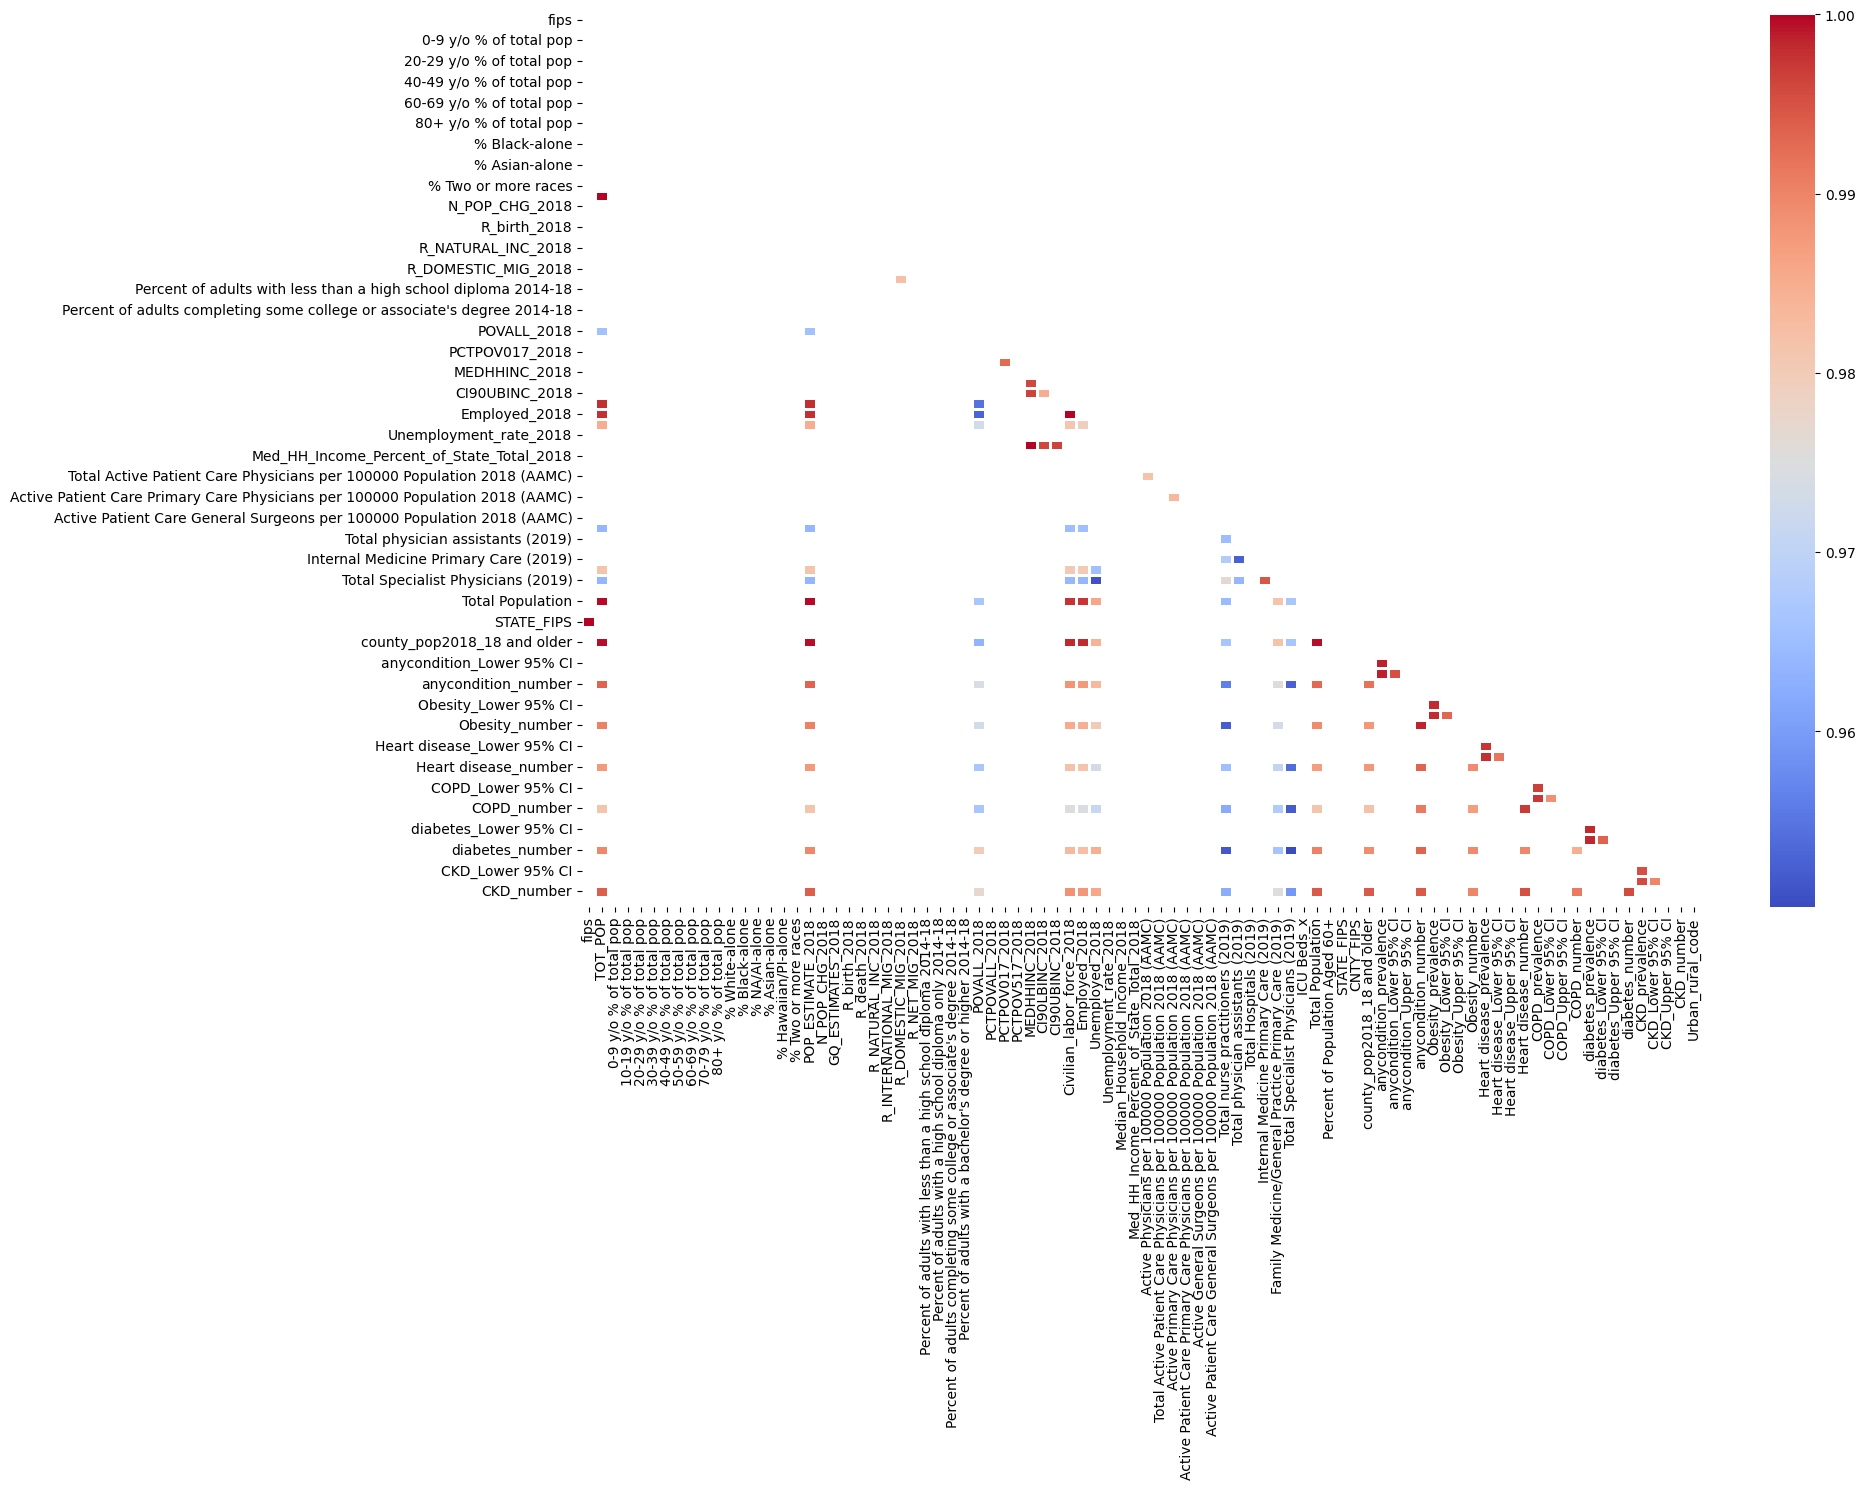

In [17]:
# Select numeric columns only
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numerical_columns.corr()
high_correlation = corr[corr > 0.95]
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(high_correlation, annot=False, mask=mask, linewidths=0.9, fmt=".2f", cmap='coolwarm')
plt.tight_layout()
plt.show()


In [18]:
# Correlations with our target
numerical_columns.corr()['ICU Beds_x'].sort_values(ascending=False)

ICU Beds_x                                                                       1.000000
COPD_number                                                                      0.922740
anycondition_number                                                              0.918752
Obesity_number                                                                   0.918087
Heart disease_number                                                             0.917757
CKD_number                                                                       0.915083
Family Medicine/General Practice Primary Care (2019)                             0.912653
county_pop2018_18 and older                                                      0.912558
Total Population                                                                 0.911363
TOT_POP                                                                          0.910824
POP_ESTIMATE_2018                                                                0.910824
Civilian_l

Conclusiones:
> Podemos eliminar la variable `MEDHHINC_2018`, porque tiene muy poca correlación con nuestro target y, al mismo tiempo, muestra una correlación muy fuerte con otras variables. También podemos eliminar `county_pop2018_18 and older` porque presenta una correlación muy alta con otras cinco variables, como `Total Population`, y la variable `COUNTY_NAME` porque tenemos `STATE_NAME` que captura información geográfica relevante a nivel estatal.

In [19]:
df.drop(['MEDHHINC_2018', 'county_pop2018_18 and older', 'COUNTY_NAME'], axis=1, inplace=True)
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Alabama,1,1,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Alabama,1,3,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,27.0,35.7,25.1,12.2,6788,30.9,43.9,36.7,31157,37607,8373,7940,433,5.2,34382,68.9,217.1,196.7,77.2,71.2,7.6,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Alabama,1,5,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,22400,-155,2151,11.1,11.4,-0.3,0.4,-7.0,-6.6,16.8,47.3,24.4,11.5,4400,21.8,27.8,26.3,41283,50845,8661,8317,344,4.0,46064,92.

### Análisis numérico-categórico (completo)

In [20]:
df['STATE_NAME_n'] = pd.factorize(df['STATE_NAME'])[0]

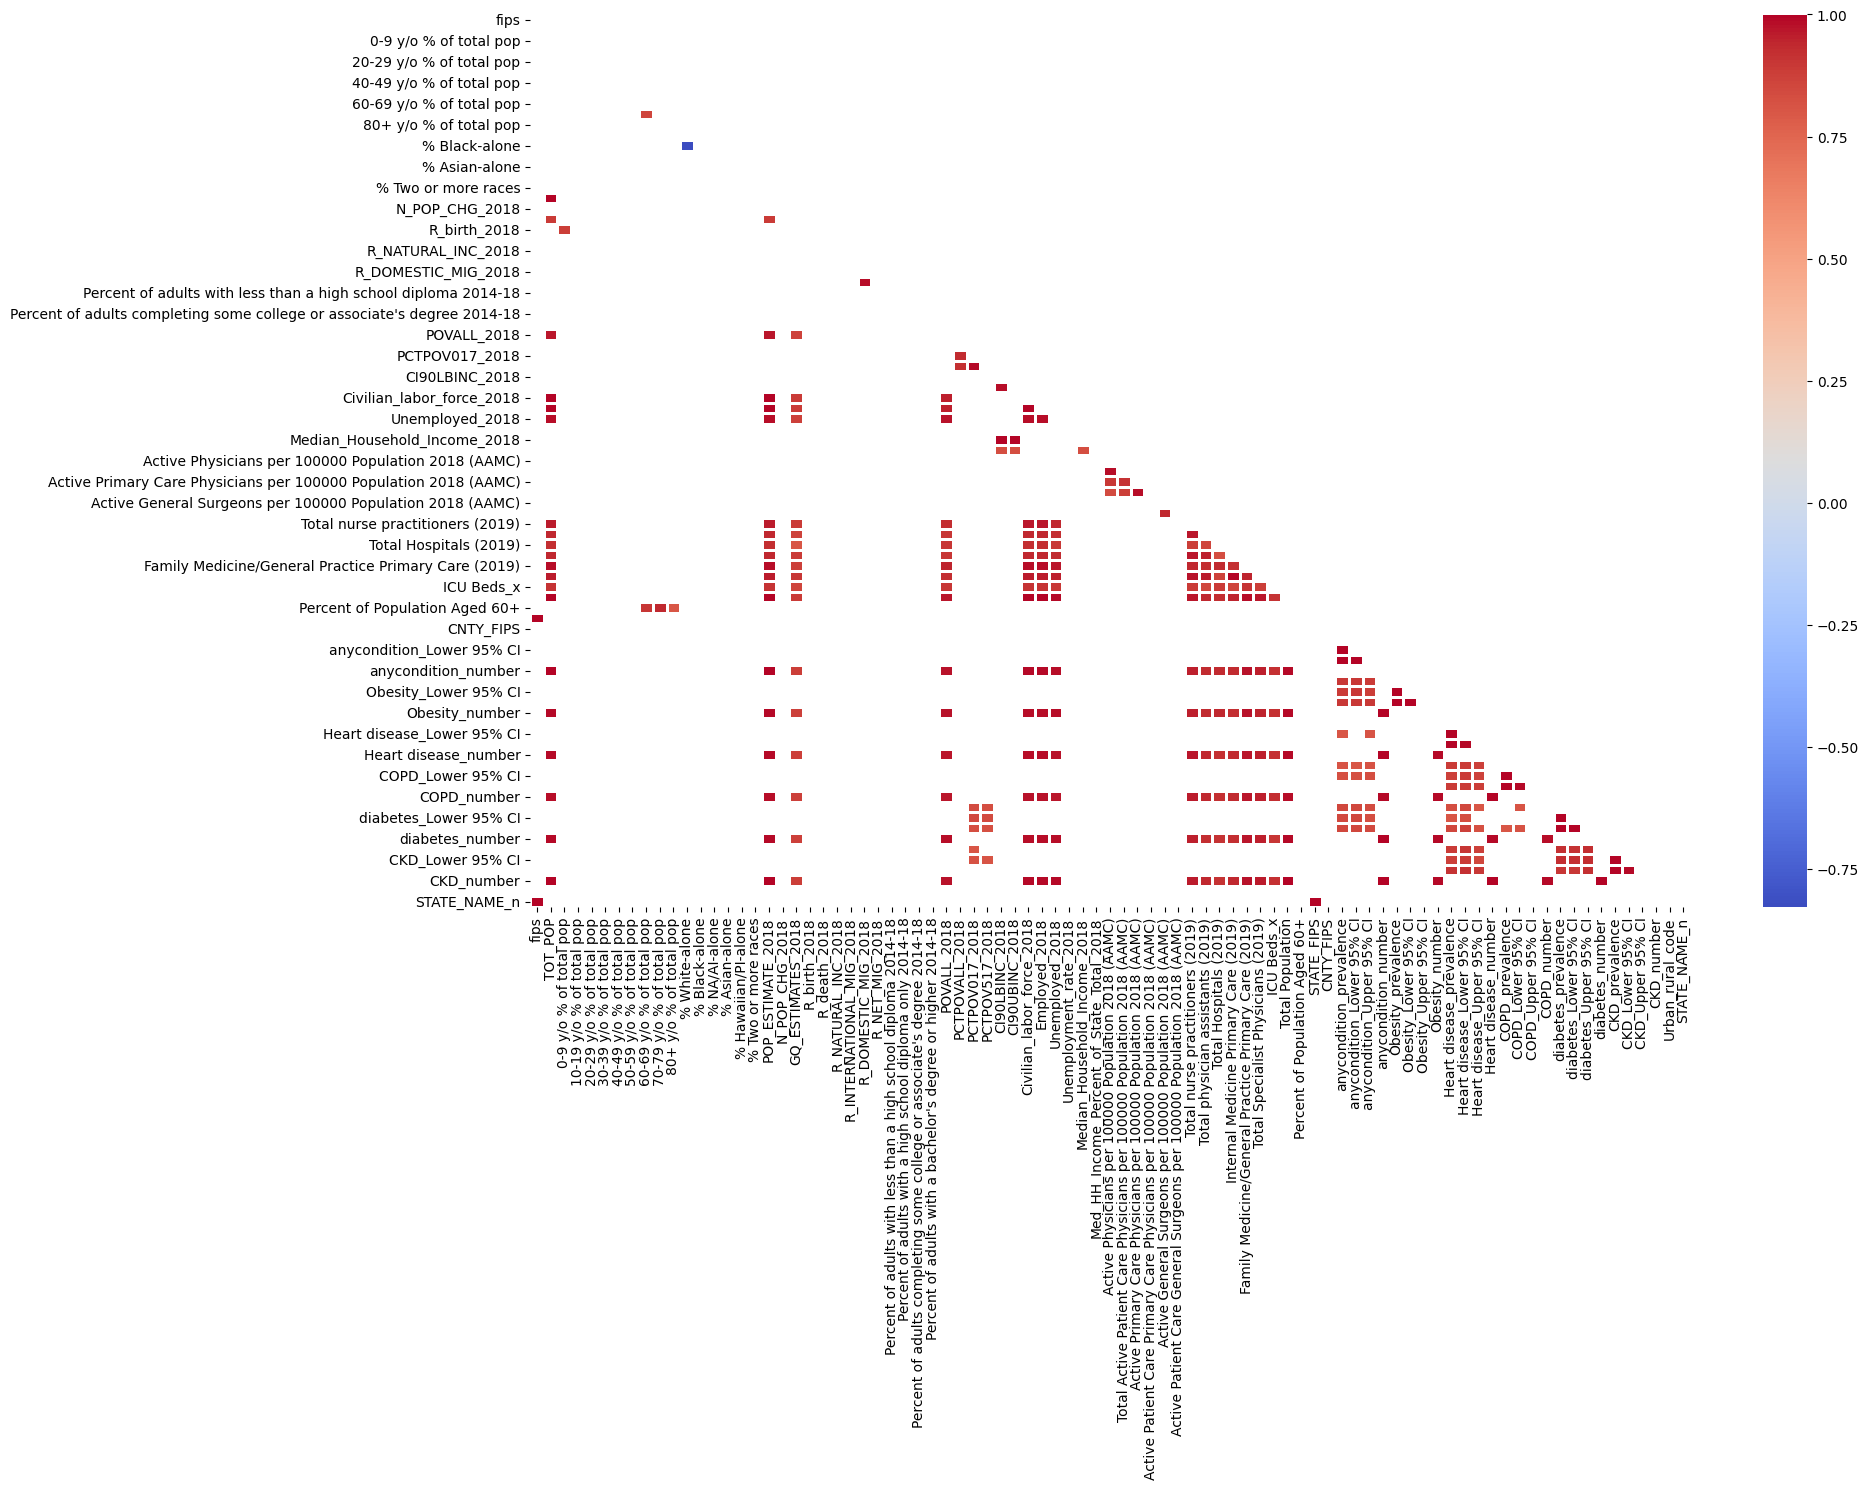

In [21]:
all_numerical_columns = df.select_dtypes(include=['int64', 'float64'])
corr = all_numerical_columns.corr()
high_correlation = corr[corr.abs() > 0.80]
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(high_correlation, annot=False, mask=mask, linewidths=0.9, fmt=".2f", cmap='coolwarm')
plt.tight_layout()
plt.show()


### Outliers: Visualización

In [22]:
df.shape

(3140, 86)

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.000000,18180.500000,29178.000000,45081.500000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.000000,10963.250000,25800.500000,67913.000000,1.010552e+07
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.000000,10.594639,11.802727,12.951840,2.546068e+01
10-19 y/o % of total pop,3140.0,12.694609,1.815044,0.000000,11.674504,12.687422,13.659282,2.330437e+01
20-29 y/o % of total pop,3140.0,12.283979,3.126297,0.000000,10.496774,11.772649,13.182260,3.757020e+01
30-39 y/o % of total pop,3140.0,11.751535,1.696599,6.092789,10.689322,11.580861,12.639379,2.222513e+01
40-49 y/o % of total pop,3140.0,11.556685,1.372935,2.631579,10.685197,11.618372,12.386083,1.943037e+01
50-59 y/o % of total pop,3140.0,13.526733,1.481692,5.316361,12.738561,13.621339,14.429115,2.045455e+01
60-69 y/o % of total pop,3140.0,13.182225,2.532498,3.444403,11.621232,13.013409,14.467254,2.727273e+01
70-79 y/o % of total pop,3140.0,8.399382,2.214915,2.199551,7.032275,8.208162,9.445777,3.132796e+01


> Las variables porcentuales no tendrán valores extremos reales, porque los porcentajes están acotados entre 0 y 100. Si un porcentaje es muy alto o muy bajo, suele reflejar una característica demográfica real, no un error.
> Vamos a analizar las variables con valores absolutos que tienen mayor correlación con nuestro target.

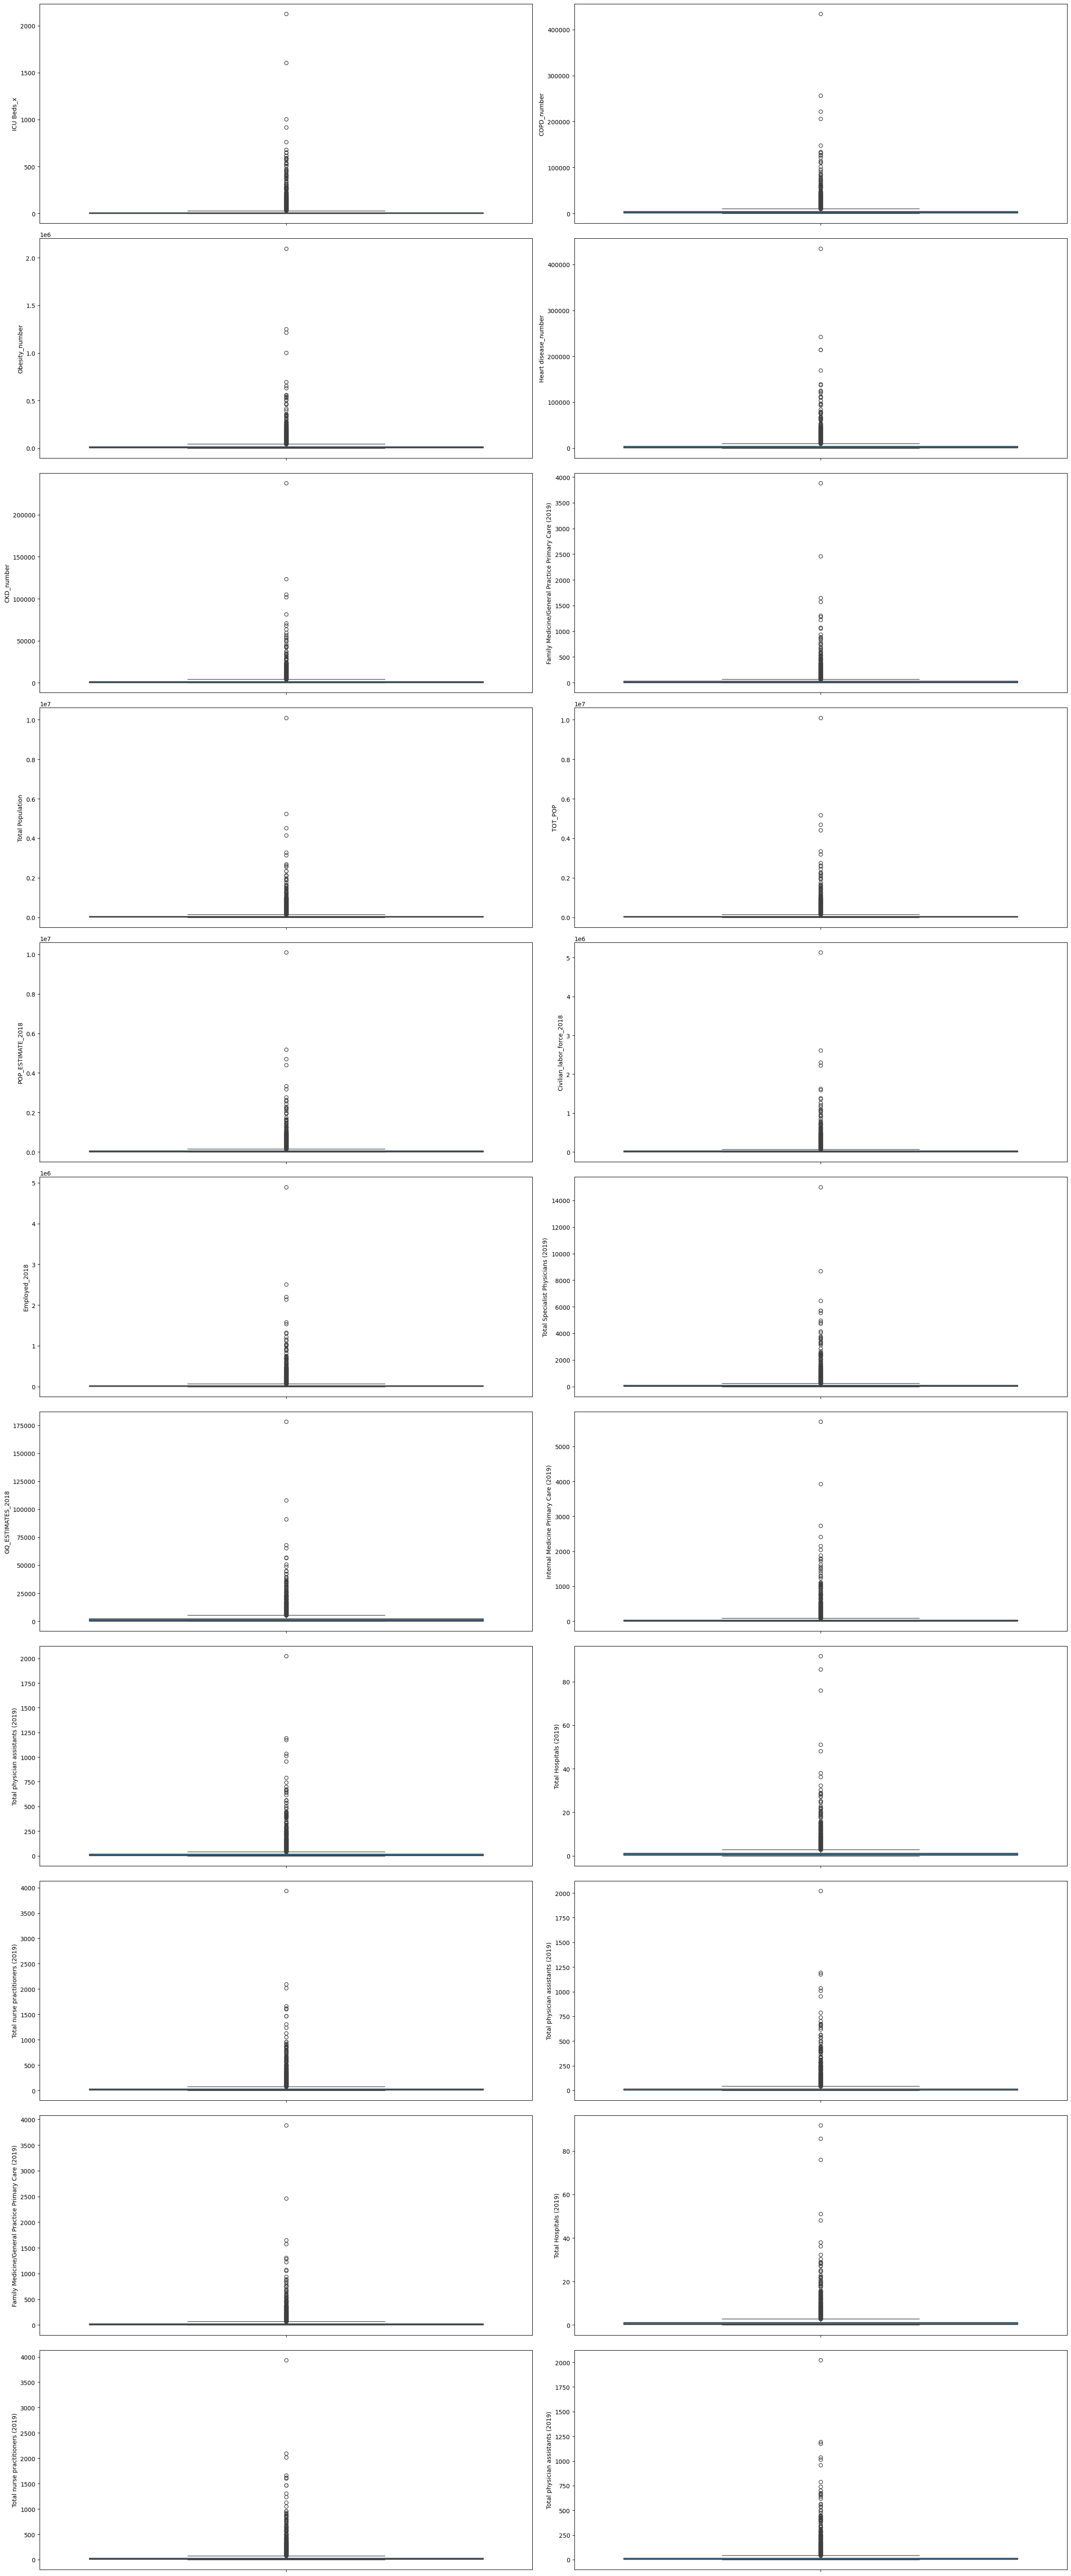

In [24]:
fig, axis = plt.subplots(11, 2, figsize=(25, 60))

sns.boxplot(ax=axis[0, 0], data=df, y='ICU Beds_x')
sns.boxplot(ax=axis[0, 1], data=df, y='COPD_number')
sns.boxplot(ax=axis[1, 0], data=df, y='Obesity_number')
sns.boxplot(ax=axis[1, 1], data=df, y='Heart disease_number')
sns.boxplot(ax=axis[2, 0], data=df, y='CKD_number')
sns.boxplot(ax=axis[2, 1], data=df, y='Family Medicine/General Practice Primary Care (2019)')
sns.boxplot(ax=axis[3, 0], data=df, y='Total Population')
sns.boxplot(ax=axis[3, 1], data=df, y='TOT_POP')
sns.boxplot(ax=axis[4, 0], data=df, y='POP_ESTIMATE_2018')
sns.boxplot(ax=axis[4, 1], data=df, y='Civilian_labor_force_2018')
sns.boxplot(ax=axis[5, 0], data=df, y='Employed_2018')
sns.boxplot(ax=axis[5, 1], data=df, y='Total Specialist Physicians (2019)')
sns.boxplot(ax=axis[6, 0], data=df, y='GQ_ESTIMATES_2018')
sns.boxplot(ax=axis[6, 1], data=df, y='Internal Medicine Primary Care (2019)')
sns.boxplot(ax=axis[7, 0], data=df, y='Total physician assistants (2019)')
sns.boxplot(ax=axis[7, 1], data=df, y='Total Hospitals (2019)')
sns.boxplot(ax=axis[8, 0], data=df, y='Total nurse practitioners (2019)')
sns.boxplot(ax=axis[8, 1], data=df, y='Total physician assistants (2019)')
sns.boxplot(ax=axis[9, 0], data=df, y='Family Medicine/General Practice Primary Care (2019)')
sns.boxplot(ax=axis[9, 1], data=df, y='Total Hospitals (2019)')
sns.boxplot(ax=axis[10, 0], data=df, y='Total nurse practitioners (2019)')
sns.boxplot(ax=axis[10, 1], data=df, y='Total physician assistants (2019)')

plt.tight_layout()
plt.show()

> #### Observaciones:
> Tenemos 88 columnas en total. Hemos creado los gráficos de las que tienen mayor correlación con nuestro target, pero antes de tratar los outliers vamos a continuar con nuestro modelo para comprobar si es necesario ajustar algo. 

### Split (dos métodos o enfoques)

In [25]:
df.drop(['STATE_NAME_n'], axis=1, inplace=True)
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Alabama,1,1,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Alabama,1,3,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,27.0,35.7,25.1,12.2,6788,30.9,43.9,36.7,31157,37607,8373,7940,433,5.2,34382,68.9,217.1,196.7,77.2,71.2,7.6,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Alabama,1,5,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,22400,-155,2151,11.1,11.4,-0.3,0.4,-7.0,-6.6,16.8,47.3,24.4,11.5,4400,21.8,27.8,26.3,41283,50845,8661,8317,344,4.0,46064,92.

In [26]:
X = df.drop('ICU Beds_x', axis=1)
y = df['ICU Beds_x']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [27]:
X_train.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
1628,30065,4651,9.331327,11.287895,8.277790,9.159321,10.771877,14.706515,20.124704,10.965384,5.375188,93.033756,0.774027,1.978069,1.870565,0.043002,2.300581,4651,6,52,8.2,13.6,-5.4,1.5,5.4,6.9,10.5,42.5,32.9,14.1,691,15.0,27.2,25.6,38854,47888,2267,2170,97,4.3,43371,78.5,247.1,236.2,91.5,88.0,9.8,9.4,2.206621,1.711882,0.245180,1.506106,2.570012,5.043704,4766,33.4,Montana,30,65,45.9,43.5,48.0,1736,35.1,33.1,36.8,1329,10.7,9.7,11.8,407,10.3,8.8,11.7,389,14.5,13.3,15.7,550,4.1,3.8,4.5,156,6
863,19153,487204,14.034573,13.237781,14.254809,14.955542,12.584872,12.359915,10.068472,5.404923,3.099112,84.986166,7.072397,0.386286,5.077545,0.075123,2.402484,487204,6118,9468,14.2,7.5,6.7,2.3,3.5,5.9,8.5,24.8,30.6,36.1,47499,9.9,11.7,11.0,65793,71165,264356,257650,6706,2.5,68479,114.0,218.2,193.1,84.8,77.9,6.9,6.5,296.692987,131.674879,18.215282,197.280769,333.586652,630.897106,467235,17.5,Iowa,19,153,40.7,38.8,42.6,148872,35.1,33.7,36.4,128427,5.7,5.2,6.3,21031,5.6,4.7,6.6,20330,9.1,8.3,9.8,33176,2.5,2.3,2.7,9120,3
380,12125,14940,10.562249,11.164659,14.323963,14.270415,13.038822,15.167336,11.311914,6.941098,3.219545,74.283802,22.650602,0.528782,0.742972,0.040161,1.753681,14940,-529,4630,9.3,15.2,-5.9,1.1,-30.3,-29.3,23.1,37.9,30.7,8.3,2118,20.6,21.0,20.1,41423,50389,4670,4511,159,3.4,45906,82.8,265.2,240.7,86.8,80.1,6.9,6.0,8.669683,4.273817,0.152210,8.133089,5.807846,20.413737,15300,20.9,Florida,12,125,51.5,49.8,53.2,6201,37.2,36.0,38.4,4478,9.8,9.0,10.7,1183,11.4,10.1,12.7,1373,14.6,13.7,15.4,1752,3.6,3.4,3.9,437,6
1999,38023,2283,12.220762,11.519930,8.190977,10.819098,8.147175,15.812527,14.892685,10.337276,8.059571,92.991678,1.971091,0.876040,2.409111,0.043802,1.708279,2283,-8,66,8.3,6.6,1.7,10.1,-15.3,-5.2,5.8,36.7,39.0,18.4,222,10.0,13.6,12.7,52592,64838,1536,1516,20,1.3,58715,90.0,237.6,217.1,87.0,79.6,10.5,9.7,1.

In [28]:
X_test.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
2590,48139,179436,14.066854,15.277871,12.567712,13.387503,13.243162,12.869212,10.322901,5.708442,2.556343,84.819100,11.386232,0.862146,0.817562,0.147128,1.967833,179436,5800,1656,12.9,7.7,5.2,0.8,26.8,27.5,14.3,28.3,34.3,23.1,15609,8.8,14.0,13.2,73595,79989,89935,86971,2964,3.3,76792,126.7,224.8,199.9,72.9,66.5,6.2,5.4,61.892063,36.528821,3.269651,67.893718,60.091567,211.920925,164092,17.8,Texas,48,139,46.4,44.8,48.0,61039,36.4,35.2,37.5,47861,6.4,5.8,6.9,8363,6.8,5.9,7.7,8883,11.8,11.0,12.5,15490,2.9,2.7,3.1,3783,2
2946,51800,91185,13.400230,13.073422,12.177441,13.890443,12.544826,14.343368,10.914076,6.469266,3.186928,52.348522,42.409388,0.411252,1.870922,0.128311,2.831606,91185,910,992,12.9,9.2,3.7,0.9,5.4,6.3,11.2,28.1,32.6,28.1,9846,10.9,16.1,15.8,65114,74392,44014,42595,1419,3.2,69753,96.1,263.2,231.8,90.3,81.7,7.3,6.3,47.938663,22.502695,1.027716,45.476427,39.920338,125.809550,88057,19.7,Virginia,51,800,49.1,47.1,50.8,33909,37.1,35.6,38.3,25619,6.8,6.2,7.3,4674,7.0,6.2,7.9,4856,12.7,11.9,13.5,8779,3.1,2.9,3.3,2126,2
1902,37029,10710,11.213819,13.669468,10.037348,12.586368,13.902894,15.098039,12.119514,7.880486,3.492063,82.502334,11.970121,0.550887,2.194211,0.093371,2.689076,10710,149,17,8.5,5.4,3.1,1.4,9.3,10.7,14.4,28.9,38.8,17.9,884,8.3,9.9,9.0,58833,73077,4650,4477,173,3.7,65955,122.3,255.0,223.5,86.2,78.1,7.1,6.2,4.865266,4.375335,0.115520,5.213890,4.150483,15.449823,10336,20.9,North Carolina,37,29,46.2,44.0,48.3,3819,34.4,32.6,35.9,2843,7.8,7.1,8.5,645,8.5,7.4,9.7,703,12.1,11.3,13.0,1003,3.1,2.9,3.4,259,5
335,12037,11736,8.980913,8.571915,12.798228,12.866394,11.417860,13.709952,15.857192,11.400818,4.396728,84.057601,12.397751,0.996933,0.485685,0.076687,1.985344,11736,-16,1464,8.2,8.5,-0.3,1.4,-2.4,-1.0,19.7,35.7,27.4,17.1,2343,22.8,36.6,35.7,35911,44683,4840,4673,167,3.5,40297,72.7,265.2,240.7,86

In [29]:
X_train.shape

(2512, 84)

In [30]:
X_test.shape

(628, 84)

### Encoding - One Hot Encoding

> Para la variable `STATE_NAME` utilizamos el metodo One Hot encoding porque tenemos pocas categorías.

In [31]:
# To generate a list with the names of the categorical columns
categorical_variable = ['STATE_NAME']

# We create the encoder instance
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# We train the encoder with the training data (we adjust it).
onehot_encoder.fit(X_train[categorical_variable])

# We apply the encoder to the training set: X_train
X_train_cat_ohe = onehot_encoder.transform(X_train[categorical_variable])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=onehot_encoder.get_feature_names_out(categorical_variable))

# We apply the encoder to the test set: X_test
X_test_cat_ohe = onehot_encoder.transform(X_test[categorical_variable])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=onehot_encoder.get_feature_names_out(categorical_variable))

X_train_cat_ohe.head()

,STATE_NAME_Alabama,STATE_NAME_Alaska,STATE_NAME_Arizona,STATE_NAME_Arkansas,STATE_NAME_California,STATE_NAME_Colorado,STATE_NAME_Connecticut,STATE_NAME_Delaware,STATE_NAME_District of Columbia,STATE_NAME_Florida,STATE_NAME_Georgia,STATE_NAME_Hawaii,STATE_NAME_Idaho,STATE_NAME_Illinois,STATE_NAME_Indiana,STATE_NAME_Iowa,STATE_NAME_Kansas,STATE_NAME_Kentucky,STATE_NAME_Louisiana,STATE_NAME_Maine,STATE_NAME_Maryland,STATE_NAME_Massachusetts,STATE_NAME_Michigan,STATE_NAME_Minnesota,STATE_NAME_Mississippi,STATE_NAME_Missouri,STATE_NAME_Montana,STATE_NAME_Nebraska,STATE_NAME_Nevada,STATE_NAME_New Hampshire,STATE_NAME_New Jersey,STATE_NAME_New Mexico,STATE_NAME_New York,STATE_NAME_North Carolina,STATE_NAME_North Dakota,STATE_NAME_Ohio,STATE_NAME_Oklahoma,STATE_NAME_Oregon,STATE_NAME_Pennsylvania,STATE_NAME_Rhode Island,STATE_NAME_South Carolina,STATE_NAME_South Dakota,STATE_NAME_Tennessee,STATE_NAME_Texas,STATE_NAME_Utah,STATE_NAME_Vermont,STATE_NAME_Virginia,STATE_NAME_Washington,STATE_NAME_West Virginia,STATE_NAME_Wisconsin,STATE_NAME_Wyoming
1628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
863,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
548,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Scaling - Escalado de valores

In [32]:
# We need to select only numerical columns 
numerical_columns = X_train.select_dtypes(include=['int64','float64']).columns

In [33]:
norm_scaler = StandardScaler()

X_train_scaled_number = norm_scaler.fit_transform(X_train[numerical_columns])
X_test_scaled_number = norm_scaler.transform(X_test[numerical_columns])

# We convert it to DataFrame
X_train_cat_le_scaled = pd.DataFrame(X_train_scaled_number, 
                                     index=X_train.index,
                                     columns=numerical_columns)

X_test_cat_le_scaled = pd.DataFrame(X_test_scaled_number,
                                     index=X_test.index,
                                     columns=numerical_columns)

X_train_cat_le_scaled.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Percent of Population Aged 60+,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
1628,-0.024722,-0.296463,-1.209244,-0.783076,-1.293732,-1.527352,-0.584923,0.814901,2.763460,1.188752,0.436638,0.531353,-0.597829,-0.043613,0.088708,-0.210493,0.121088,-0.296463,-0.204640,-0.373430,-1.186867,1.219199,-1.547214,0.158176,0.472251,0.507738,-0.460916,1.143830,0.413913,-0.796536,-0.276520,-0.022439,0.689124,0.655434,-0.724178,-0.640823,-0.290018,-0.290665,-0.269159,0.123465,-0.684111,-0.552343,-0.187188,0.314119,0.275994,0.750179,1.697600,2.356637,-0.328690,-0.306294,-0.331015,-0.290551,-0.318596,-0.299891,-0.295220,1.579864,-0.022258,-0.352541,-0.135208,-0.177142,-0.125653,-0.319292,0.019533,-0.067403,0.047338,-0.321823,1.196164,1.178673,1.228998,-0.333097,0.519008,0.466305,0.488546,-0.348214,0.522866,0.460517,0.583092,-0.292432,1.154393,1.125517,1.293588,-0.298468,0.911081
863,-0.741628,1.119324,1.034084,0.304858,0.626378,1.880221,0.739763,-0.803518,-1.236114,-1.371829,-1.084760,0.044171,-0.170294,-0.250092,1.148643,-0.127459,0.189977,1.119324,1.659717,1.003083,1.213817,-1.071529,1.465714,0.515897,0.306154,0.419514,-0.781980,-1.316105,-0.027847,1.535749,0.743546,-0.857608,-1.057995,-1.013757,1.266719,0.999549,1.226714,1.250278,0.655391,-1.091991,1.134271,1.230961,-0.868143,-1.048173,-0.256840,-0.212997,-0.554695,-0.238974,1.556262,1.193723,3.846840,0.625634,2.186591,0.841716,1.085896,-1.310675,-0.745821,0.465524,-0.947378,-0.912285,-0.968904,1.149149,0.019533,0.066709,-0.039841,1.368858,-1.642858,-1.612921,-1.633463,0.980470,-1.488203,-1.498336,-1.467164,0.920554,-1.452396,-1.438211,-1.500145,0.784088,-1.659445,-1.713706,-1.642406,0.850297,-1.067566
380,-1.203360,-0.266276,-0.622125,-0.851836,0.648593,1.477437,1.071447,1.132724,-0.741571,-0.664423,-1.004259,-0.603724,0.887158,-0.231608,-0.283972,-0.217837,-0.248626,-0.266276,-0.367832,0.295822,-0.746742,1.820045,-1.671716,-0.020684,-2.648634,-2.685974,1.

In [34]:
X_train_final_scaled = pd.concat([X_train_cat_le_scaled, X_train_cat_ohe], axis=1)
X_test_final_scaled = pd.concat([X_test_cat_le_scaled, X_test_cat_ohe], axis=1)

In [35]:
X_train_final_scaled.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Total Population,Percent of Population Aged 60+,STATE_FIPS,CNTY_FIPS,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code,STATE_NAME_Alabama,STATE_NAME_Alaska,STATE_NAME_Arizona,STATE_NAME_Arkansas,STATE_NAME_California,STATE_NAME_Colorado,STATE_NAME_Connecticut,STATE_NAME_Delaware,STATE_NAME_District of Columbia,STATE_NAME_Florida,STATE_NAME_Georgia,STATE_NAME_Hawaii,STATE_NAME_Idaho,STATE_NAME_Illinois,STATE_NAME_Indiana,STATE_NAME_Iowa,STATE_NAME_Kansas,STATE_NAME_Kentucky,STATE_NAME_Louisiana,STATE_NAME_Maine,STATE_NAME_Maryland,STATE_NAME_Massachusetts,STATE_NAME_Michigan,STATE_NAME_Minnesota,STATE_NAME_Mississippi,STATE_NAME_Missouri,STATE_NAME_Montana,STATE_NAME_Nebraska,STATE_NAME_Nevada,STATE_NAME_New Hampshire,STATE_NAME_New Jersey,STATE_NAME_New Mexico,STATE_NAME_New York,STATE_NAME_North Carolina,STATE_NAME_North Dakota,STATE_NAME_Ohio,STATE_NAME_Oklahoma,STATE_NAME_Oregon,STATE_NAME_Pennsylvania,STATE_NAME_Rhode Island,STATE_NAME_South Carolina,STATE_NAME_South Dakota,STATE_NAME_Tennessee,STATE_NAME_Texas,STATE_NAME_Utah,STATE_NAME_Vermont,STATE_NAME_Virginia,STATE_NAME_Washington,STATE_NAME_West Virginia,STATE_NAME_Wisconsin,STATE_NAME_Wyoming
1628,-0.024722,-0.296463,-1.209244,-0.783076,-1.293732,-1.527352,-0.584923,0.814901,2.763460,1.188752,0.436638,0.531353,-0.597829,-0.043613,0.088708,-0.210493,0.121088,-0.296463,-0.204640,-0.373430,-1.186867,1.219199,-1.547214,0.158176,0.472251,0.507738,-0.460916,1.143830,0.413913,-0.796536,-0.276520,-0.022439,0.689124,0.655434,-0.724178,-0.640823,-0.290018,-0.290665,-0.269159,0.123465,-0.684111,-0.552343,-0.187188,0.314119,0.275994,0.750179,1.697600,2.356637,-0.328690,-0.306294,-0.331015,-0.290551,-0.318596,-0.299891,-0.295220,1.579864,-0.022258,-0.352541,-0.135208,-0.177142,-0.125653,-0.319292,0.019533,-0.067403,0.047338,-0.321823,1.196164,1.178673,1.228998,-0.333097,0.519008,0.466305,0.488546,-0.348214,0.522866,0.460517,0.583092,-0.292432,1.154393,1.125517,1.293588,-0.298468,0.9110

## Paso 3:  Construcción de modelo de regresión

### Evaluación del modelo

#### Modelo de Regresión Lineal

In [36]:
# Model
lr_model = LinearRegression()

# Training
lr_model.fit(X_train_final_scaled, y_train)

# Prediction
lr_y_pred_train = lr_model.predict(X_train_final_scaled)
lr_y_pred_test = lr_model.predict(X_test_final_scaled)

get_regression_metrics(lr_y_pred_test, y_test, lr_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.910209,5.892354,1.378248e+18,623.239915,24.964773
Test set,0.896259,5.911229,1.498179e+18,831.050255,28.827942
Difference,-0.013950,0.018875,1.199312e+17,207.810340,3.863169


> Observaciones:
>
> La regresión lineal está funcionando bastante bien ($R^2$ alto y similar en train y test, errores similares). No se aprecia un sobreajuste importante.

#### Regularización Lasso

In [37]:
lasso_model = Lasso(alpha=0.5, max_iter=400, random_state=18)
lasso_model.fit(X_train_final_scaled, y_train)

lasso_y_pred_test = lasso_model.predict(X_test_final_scaled)
lasso_y_pred_train = lasso_model.predict(X_train_final_scaled)

get_regression_metrics(lasso_y_pred_test, y_test, lasso_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.877501,5.301827,1.266146e+18,850.267984,29.159355
Test set,0.912185,5.504218,1.441589e+18,703.469181,26.522993
Difference,0.034684,0.202390,1.754424e+17,-146.798803,-2.636362


> Observaciones:
>
> El modelo Lasso está funcionando bien, explica una gran parte de la variación del target con errores similares en train y test, sin overfitting apreciable y con la ventaja de la regularización.

### Regularización Ridge

In [38]:
ridge_model = Ridge(alpha=0.0001,
                    max_iter=5000,
                    random_state=18).fit(X_train_final_scaled, y_train)
ridge_y_pred_test = ridge_model.predict(X_test_final_scaled)
ridge_y_pred_train = ridge_model.predict(X_train_final_scaled)

get_regression_metrics(ridge_y_pred_test, y_test, ridge_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.910134,5.930509,1.375833e+18,623.759608,24.97518
Test set,0.896443,6.007540,1.502407e+18,829.576496,28.80237
Difference,-0.013692,0.077031,1.265743e+17,205.816888,3.82719


> Observaciones:
>
> El modelo Ridge logra explicar alrededor del 90 % de la variabilidad del objetivo ($R^2$ alto en train y test) y presenta errores medios moderados y muy similares entre entrenamiento y prueba.

#### LassoCV

In [39]:
lasso_cv_model = (LassoCV(alphas=np.logspace(-6, 6, 10),
                         cv=5,
                         random_state=18,
                         n_jobs=-1).fit(X_train_final_scaled, y_train))

lasso_cv_y_pred_test = lasso_cv_model.predict(X_test_final_scaled)
lasso_cv_y_pred_train = lasso_cv_model.predict(X_train_final_scaled)

get_regression_metrics(lasso_cv_y_pred_test, y_test, lasso_cv_y_pred_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.373e+05, tolerance: 1.104e+03
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.297e+05, tolerance: 1.104e+03
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Dual

,R2,MAE,MAPE,MSE,RMSE
Train set,0.904220,6.322751,1.473537e+18,664.812944,25.783967
Test set,0.909288,6.655647,1.644402e+18,726.679724,26.956998
Difference,0.005068,0.332896,1.708656e+17,61.866779,1.173031


> Observaciones:
>
> El $R^2$ es cercano a 0.90 tanto en entrenamiento como en prueba, lo que indica que el modelo explica alrededor del 90 % de la variabilidad de la variable objetivo.

#### RidgeCV

In [40]:
ridge_cv_model = RidgeCV(alphas=np.logspace(-6, 6, 10),
                         cv=5).fit(X_train_final_scaled, y_train)

ridge_cv_y_pred_test = ridge_cv_model.predict(X_test_final_scaled)
ridge_cv_y_pred_train = ridge_cv_model.predict(X_train_final_scaled)

get_regression_metrics(ridge_cv_y_pred_test, y_test, ridge_cv_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.907618,6.063059,1.412998e+18,641.229123,25.322502
Test set,0.905728,6.342432,1.588406e+18,755.195265,27.480816
Difference,-0.001890,0.279373,1.754076e+17,113.966142,2.158314


> Observaciones:
>
> RidgeCV ofrece un buen ajuste y una buena capacidad de generalización, capturando de forma sólida la relación entre las variables predictoras y la variable objetivo.

#### ElasticNet

In [41]:
elasticnet_model = ElasticNet(alpha=0.0001,
                              max_iter=400,
                              random_state=18).fit(X_train_final_scaled, y_train)

elasticnet_y_pred_test = elasticnet_model.predict(X_test_final_scaled)
elasticnet_y_pred_train = elasticnet_model.predict(X_train_final_scaled)
get_regression_metrics(elasticnet_y_pred_test, y_test, elasticnet_y_pred_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.835e+05, tolerance: 1.744e+03
  model = cd_fast.enet_coordinate_descent(


,R2,MAE,MAPE,MSE,RMSE
Train set,0.899034,6.855165,1.620659e+18,700.804748,26.472717
Test set,0.905415,7.216519,1.868343e+18,757.700926,27.526368
Difference,0.006381,0.361354,2.476837e+17,56.896178,1.053651


> Observaciones:
>
> El $R^2$ es aproximadamente 0.90 en el conjunto de entrenamiento y algo superior en el de prueba (~0.91), lo que indica que el modelo explica alrededor del 90 % de la variabilidad de la variable objetivo.

>Conclusiones: 
>
> Todos los modelos lineales (Regresión Lineal, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet) muestran R² ≈ 0.89 – 0.91 en train y test, alrededor del 90 % de la variabilidad del objetivo. MAE y RMSE muy similares entre train y test, los modelos generalizan bien, sin sobreajuste fuerte.
> Si necesitamos elegir un modelo, LassoCV podría ser nuestro modelo final, porque mantiene un $R^2$ y unos errores muy similares al resto. 


## Paso 4: Optimización del modelo de regresión

> Observaciones:
>
> Con los resultados que hemos obtenido, podríamos dejar el modelo como está, porque el $R^2$ está alrededor de 0.90 tanto en train como en test. Igualmente, podemos ajustar alpha para ver si podemos conseguir un modelo mejor.

In [42]:
lasso_cv_best_model = (LassoCV(alphas=np.logspace(-4, 2, 20),
                         cv=5,
                         random_state=18,
                         n_jobs=-1).fit(X_train_final_scaled, y_train))

lasso_cv_best_model

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.765e+04, tolerance: 1.104e+03
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.984e+04, tolerance: 1.104e+03
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Dual

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.975e+05, tolerance: 1.376e+03
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.140e+04, tolerance: 1.439e+03
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Dual

,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+02])
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,-1


In [43]:
lasso_cv_best_y_pred_test = lasso_cv_best_model.predict(X_test_final_scaled)
lasso_cv_best_y_pred_train = lasso_cv_best_model.predict(X_train_final_scaled)

get_regression_metrics(lasso_cv_y_pred_test, y_test, lasso_cv_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.904220,6.322751,1.473537e+18,664.812944,25.783967
Test set,0.909288,6.655647,1.644402e+18,726.679724,26.956998
Difference,0.005068,0.332896,1.708656e+17,61.866779,1.173031


> Observaciones:
>
> Al optimizar los hiperparámetros con LassoCV, el rendimiento del modelo se mantiene en niveles muy altos ($R^2$ ≈ 0.90, errores similares entre train y test).